# Lab assignment №1, part 3

This lab assignment consists of several parts. You are supposed to make some transformations, train some models, estimate the quality of the models and explain your results.

Several comments:
* Don't hesitate to ask questions, it's a good practice.
* No private/public sharing, please. The copied assignments will be graded with 0 points.
* Blocks of this lab will be graded separately.

__*This is the third part of the assignment. First and second parts are waiting for you in the same directory.*__

##  Part 3. SVM and kernels

Kernels concept get adopted in variety of ML algorithms (e.g. Kernel PCA, Gaussian Processes, kNN, ...).

So in this task you are to examine kernels for SVM algorithm applied to rather simple artificial datasets.

To make it clear: we will work with the classification problem through the whole notebook. 

In [1]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

Let's generate our dataset and take a look on it.

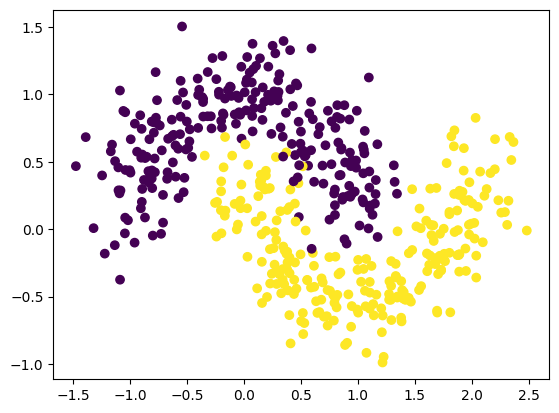

In [2]:
moons_points, moons_labels = make_moons(n_samples=500, noise=0.2, random_state=42)
plt.scatter(moons_points[:, 0], moons_points[:, 1], c=moons_labels)

## 1.1 Pure models.
First let's try to solve this case with good old Logistic Regression and simple (linear kernel) SVM classifier.

Train LR and SVM classifiers (choose params by hand, no CV or intensive grid search neeeded) and plot their decision regions. Calculate one preffered classification metric.

Describe results in one-two sentences.

_Tip:_ to plot classifiers decisions you colud use either sklearn examples ([this](https://scikit-learn.org/stable/auto_examples/neural_networks/plot_mlp_alpha.html#sphx-glr-auto-examples-neural-networks-plot-mlp-alpha-py) or any other) and mess with matplotlib yourself or great [mlxtend](https://github.com/rasbt/mlxtend) package (see their examples for details)

_Pro Tip:_ wirte function `plot_decisions` taking a dataset and an estimator and plotting the results cause you want to use it several times below

In [3]:
# хоть нас и не просят поделить на train test, все таки поделим, потому что оценивать качество на том же датасете,
# на котором обучались как-то неправильно

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(moons_points, moons_labels, test_size=0.2)

In [5]:
# !pip install mlxtend

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import f1_score
from mlxtend.plotting import plot_decision_regions

lr_params = {
    'random_state': 10,
    'n_jobs': -1,
    'solver': 'lbfgs'
}

cvm_params = {
    'kernel': 'linear',
    'C': 1,
}

lr = LogisticRegression(**lr_params)
lr.fit(X_train, y_train)

svm = SVC(**cvm_params)
svm.fit(X_train, y_train)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [7]:
lr_pred = lr.predict(X_test)
log_reg_f1 = f1_score(y_test, lr_pred)

svm_pred = svm.predict(X_test)
svm_f1 = f1_score(y_test, svm_pred)

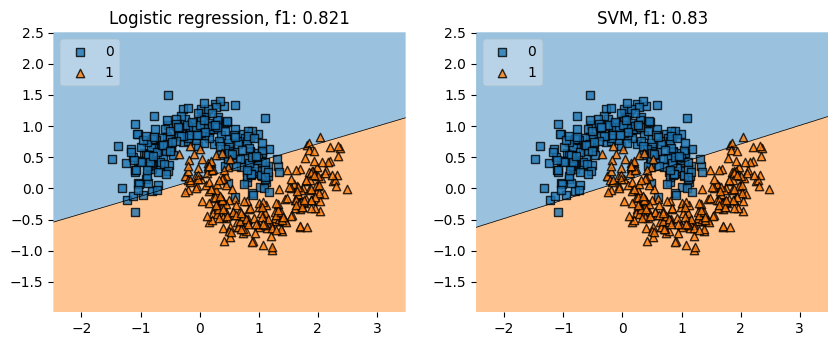

In [8]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 2)

ax = plt.subplot(gs[0, 0])
# отрисуем на всем датасете, если рисовать только на тестовой части получаются неинформативная некрасивая картинка
fig = plot_decision_regions(X=moons_points, y=moons_labels, clf=lr, legend=2)
plt.title(f'Logistic regression, f1: {log_reg_f1:.03}')

ax = plt.subplot(gs[0, 1])
fig = plot_decision_regions(X=moons_points, y=moons_labels, clf=svm, legend=2)
plt.title(f'SVM, f1: {svm_f1:.03}')

plt.show()

## 1.2 Kernel tirck

Now use different kernels (`poly`, `rbf`, `sigmoid`) on SVC to get better results. Play `degree` parameter and others.

For each kernel estimate optimal params, plot decision regions, calculate metric you've chosen eariler.

Write couple of sentences on:

* What have happenned with classification quality?
* How did decision border changed for each kernel?
* What `degree` have you chosen and why?

In [9]:
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm

In [10]:
# Найдем для каждого ядра лучшее сочетание параметров

param_grid = {
    'C': np.arange(1.0, 5.0, 0.2),
    'degree': np.arange(2, 5, 1),
    'random_state': [10],
    'break_ties': [True, False]
}

kernels = ['linear', 'poly', 'rbf', 'sigmoid']

In [11]:
results = []
for kernel in tqdm(kernels):
    param_grid.update({'kernel': [kernel]})
    svm_gs = GridSearchCV(SVC(), param_grid, scoring='roc_auc', verbose=1, n_jobs=-1)
    svm_gs.fit(X_train, y_train)
    results.append(svm_gs)

  0%|                                                                                                                                                                                                  | 0/4 [00:00<?, ?it/s]

Fitting 5 folds for each of 120 candidates, totalling 600 fits


 25%|██████████████████████████████████████████████▌                                                                                                                                           | 1/4 [00:01<00:03,  1.08s/it]

Fitting 5 folds for each of 120 candidates, totalling 600 fits


 50%|█████████████████████████████████████████████████████████████████████████████████████████████                                                                                             | 2/4 [00:01<00:01,  1.29it/s]

Fitting 5 folds for each of 120 candidates, totalling 600 fits


 75%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                              | 3/4 [00:01<00:00,  1.71it/s]

Fitting 5 folds for each of 120 candidates, totalling 600 fits


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:02<00:00,  1.61it/s]


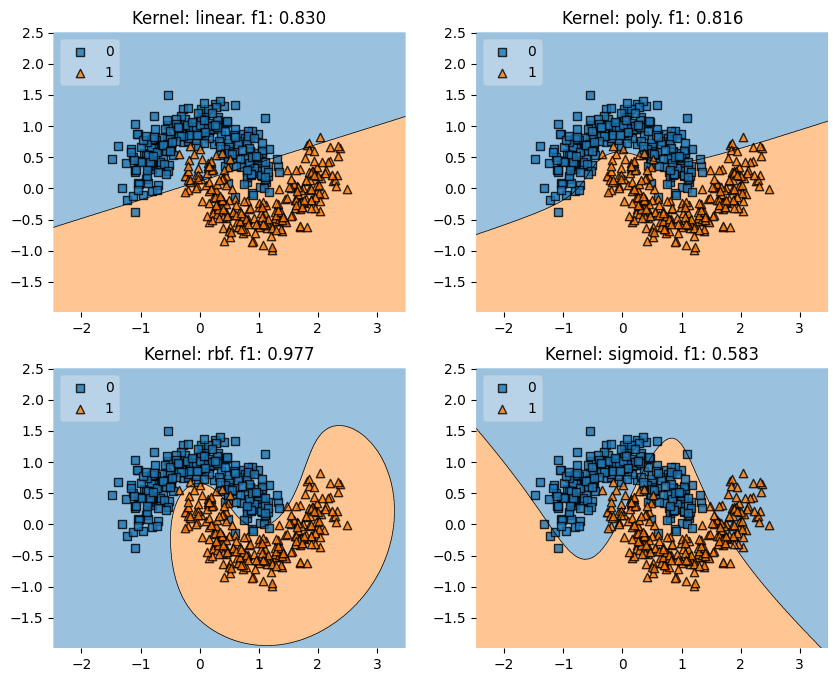

In [12]:
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 2)

for i, (gs_res, pos) in enumerate(zip(results, [(0,0), (0,1), (1,0), (1,1)])):
    y_pred = gs_res.best_estimator_.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    kernel = kernels[i]
    
    ax = plt.subplot(gs[*pos])
    fig = plot_decision_regions(X=moons_points, y=moons_labels, clf=gs_res.best_estimator_, legend=2)
    title = f"Kernel: {kernel}. f1: {f1:.3f}"
    plt.title(title)

In [13]:
for kernel, res in zip(kernels, results):
    print(kernel, res.best_params_)

linear {'C': 1.0, 'break_ties': True, 'degree': 2, 'kernel': 'linear', 'random_state': 10}
poly {'C': 1.7999999999999998, 'break_ties': True, 'degree': 3, 'kernel': 'poly', 'random_state': 10}
rbf {'C': 4.799999999999999, 'break_ties': True, 'degree': 2, 'kernel': 'rbf', 'random_state': 10}
sigmoid {'C': 1.0, 'break_ties': True, 'degree': 2, 'kernel': 'sigmoid', 'random_state': 10}


In [14]:
# Качество улучшилось в 3/4 случаев;
# Границы принятия решения соответствуют ядру - кроме 'linear' ядра все границы нелинейные;
# Степень полинома - это параметр только одного ядра - полиномиального, она в данном случае равна 3. Полиномы большей степени вообще не часто
# встречаются и мало что опиывают "в природе". Большая степень как правило приводит к ухудшению обобщающей способности.

## 1.3 Simpler solution (of a kind)
What is we could use Logisitc Regression to successfully solve this task?

Feature generation is a thing to help here. Different techniques of feature generation are used in real life, couple of them will be covered in additional lectures.

In particular case simple `PolynomialFeatures` ([link](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)) are able to save the day.

Generate the set of new features, train LR on it, plot decision regions, calculate metric.

* Comare SVM's results with this solution (quality, borders type)
* What degree of PolynomialFeatures have you used? Compare with same SVM kernel parameter.

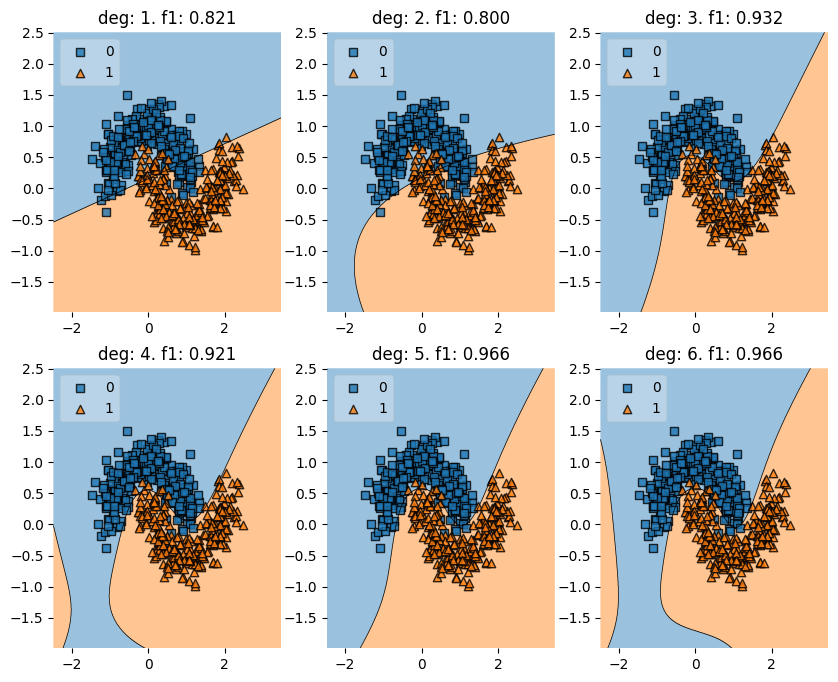

In [15]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 3)

grid_pos = [
    (0,0),(0,1), (0,2), 
    (1,0),(1,1), (1,2), 
    (2,0),(2,1), (2,2), 
]

for i, deg in enumerate(np.arange(1,7,1)):
    pipe = Pipeline([('poly', PolynomialFeatures(deg)), ('log_reg', LogisticRegression())])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    
    pos = grid_pos[i]
    
    ax = plt.subplot(gs[*pos])
    fig = plot_decision_regions(X=moons_points, y=moons_labels, clf=pipe, legend=2)
    title = f"deg: {deg}. f1: {f1:.3f}"
    plt.title(title)

In [16]:
# Чем больше степень, тем больше искривляюется граница принятия решения. При степени равной 3 получаем результат, аналогичный rbf ядру.
# Дальнейшее увеличение степени приводит к "странным" границам.

# 3 степень кажется самой адекватной, т.к. при этом сохраняются четкие интерпретируемые границы

## 1.4 Harder problem

Let's make this task a bit more challenging via upgrading dataset:

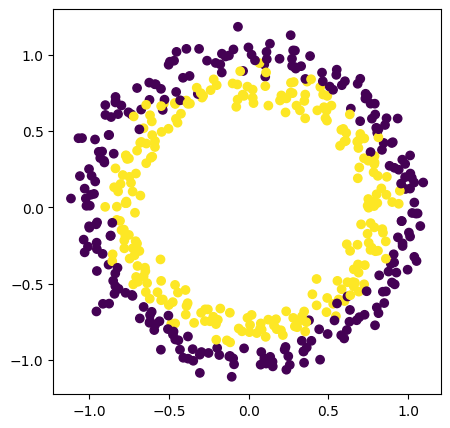

In [17]:
from sklearn.datasets import make_circles

circles_points, circles_labels = make_circles(n_samples=500, noise=0.06, random_state=42)

plt.figure(figsize=(5, 5))
plt.scatter(circles_points[:, 0], circles_points[:, 1], c=circles_labels)

And even more:

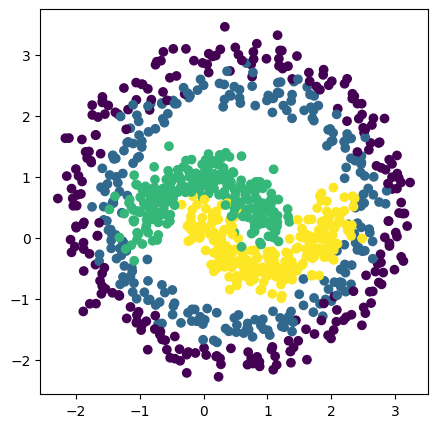

In [18]:
points = np.vstack((circles_points*2.5 + 0.5, moons_points))
labels = np.hstack((circles_labels, moons_labels + 2)) # + 2 to distinct moons classes

plt.figure(figsize=(5, 5))
plt.scatter(points[:, 0], points[:, 1], c=labels)

Now do your best using all the approaches above!

Tune LR with generated features, SVM with appropriate kernel of your choice. You may add some of your loved models to demonstrate their (and your) strength. Again plot decision regions, calculate metric.

Justify the results in a few phrases.

In [67]:
# Попробуем решить используя kernel trick

In [76]:
param_grid = {
    'C': np.arange(1.0, 5.0, 0.2),
    'degree': np.arange(2, 5, 1),
    'gamma': ['scale', 'auto'],
    'random_state': [10],
    'probability': [True],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'coef0': np.arange(0, 1, 0.1),
    'shrinking': [True, False],
    'decision_function_shape': ['ovr']
}

In [77]:
X_train, X_test, y_train, y_test = train_test_split(points, labels, test_size=0.2)

In [78]:
from sklearn.metrics import make_scorer, roc_auc_score

scorer = make_scorer(roc_auc_score, multi_class='ovr', response_method='predict_proba')

In [80]:
grid_search = GridSearchCV(SVC(), param_grid, scoring=scorer, verbose=1, cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 9600 candidates, totalling 28800 fits


,estimator,SVC()
,param_grid,"{'C': array([1. , 1....4, 4.6, 4.8]), 'coef0': array([0. , 0....7, 0.8, 0.9]), 'decision_function_shape': ['ovr'], 'degree': array([2, 3, 4]), ...}"
,scoring,make_scorer(r...lti_class=ovr)
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,4.799999999999999


In [82]:
f1 = f1_score(y_test, grid_search.best_estimator_.predict(X_test), average='macro')

In [83]:
f1

0.923581795575801

/media/alexander/D/PycharmProjects/ml-course-mipt/venv/lib/python3.12/site-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


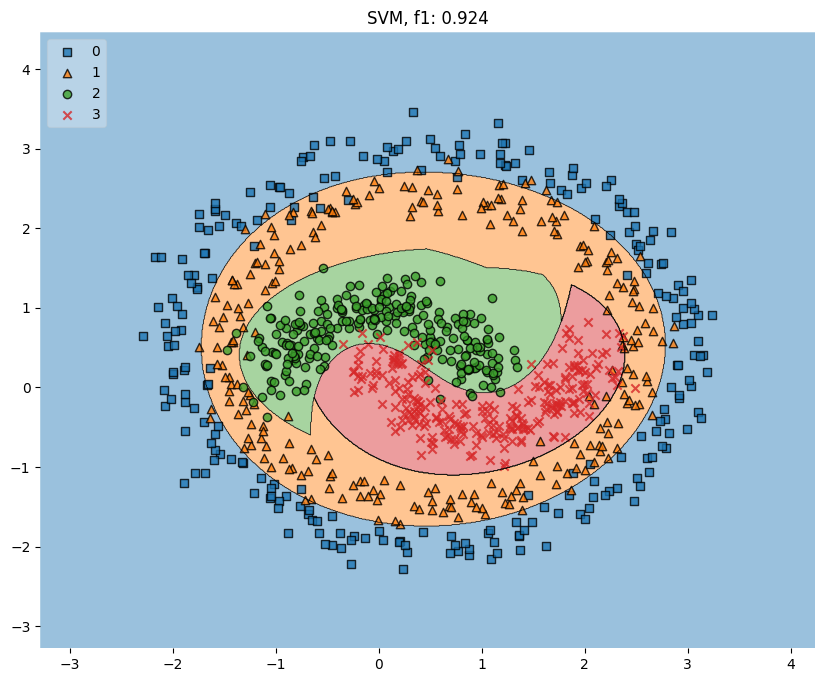

In [84]:
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(1,1)

ax = plt.subplot(gs[0, 0])
fig = plot_decision_regions(X=points, y=labels, clf=grid_search.best_estimator_, legend=2)
plt.title(f'SVM, f1: {f1:.03}')
plt.show()

In [99]:
grid_search.best_params_

{'C': 4.799999999999999,
 'coef0': 0.5,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'auto',
 'kernel': 'poly',
 'probability': True,
 'random_state': 10,
 'shrinking': True}

In [85]:
# not bad!

In [86]:
# Теперь тоже самое, только с полиномами

In [87]:
pipe = Pipeline([('poly', PolynomialFeatures(deg)), ('log_reg', LogisticRegression())])

In [92]:
param_grid = {
        'poly__degree': np.arange(1,5,1),
        'poly__include_bias': [True, False],
        'log_reg__penalty': ['l1', 'l2', 'elasticnet'],
        'log_reg__C': np.arange(1,3,0.5),
        'log_reg__solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
        'log_reg__multi_class': ['ovr'],
        'log_reg__l1_ratio': np.arange(0,1, 0.2),
    }

In [93]:
grid_search_pipe = GridSearchCV(pipe, param_grid, scoring=scorer, verbose=1, cv=3, n_jobs=-1)
grid_search_pipe.fit(X_train, y_train)

Fitting 3 folds for each of 2880 candidates, totalling 8640 fits


/media/alexander/D/PycharmProjects/ml-course-mipt/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/media/alexander/D/PycharmProjects/ml-course-mipt/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/media/alexander/D/PycharmProjects/ml-course-mipt/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/media/alexande

,estimator,Pipeline(step...egression())])
,param_grid,"{'log_reg__C': array([1. , 1.5, 2. , 2.5]), 'log_reg__l1_ratio': array([0. , 0....4, 0.6, 0.8]), 'log_reg__multi_class': ['ovr'], 'log_reg__penalty': ['l1', 'l2', ...], ...}"
,scoring,make_scorer(r...lti_class=ovr)
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,degree,4


In [95]:
f1 = f1_score(y_test, grid_search_pipe.best_estimator_.predict(X_test), average='macro')

In [96]:
f1

0.9277455615519912

/media/alexander/D/PycharmProjects/ml-course-mipt/venv/lib/python3.12/site-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


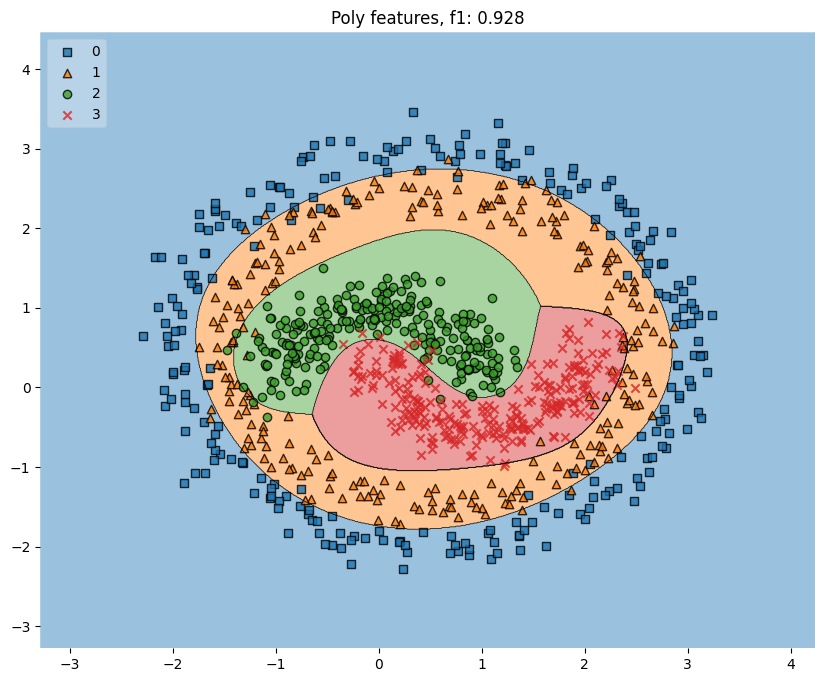

In [97]:
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(1,1)

ax = plt.subplot(gs[0, 0])
fig = plot_decision_regions(X=points, y=labels, clf=grid_search_pipe.best_estimator_, legend=2)
plt.title(f'Poly features, f1: {f1:.03}')
plt.show()

In [98]:
grid_search_pipe.best_params_

{'log_reg__C': 2.5,
 'log_reg__l1_ratio': 0.4,
 'log_reg__multi_class': 'ovr',
 'log_reg__penalty': 'l1',
 'log_reg__solver': 'liblinear',
 'poly__degree': 4,
 'poly__include_bias': True}

In [101]:
# Тоже очень неплохо :) даже чуть-чуть лучше, чем svm.

In [100]:
# Получили достаточно неплохой результат: точность по метрике f1 0.924 и 0.928 для svm и регрессии со взаимодействием признаков
# соответственно. 

# Выводы: разны ядра svm и трюк с полиномиальным взаимодействием признаков дают похожие результаты. Варьируя параметры, можно добиться
# нелинейной и при этом интуитивно адекватной границы приниятия решений.